# Stage 7 — Responsible AI Evaluation (Memory-Safe Version)

**Project:** Heart_Attack_Risk_Assessment  
**Team:** team05 | **Student:** s502  
**Course:** ITI113 | **Semester:** 26S1

This version is optimized for a modest SageMaker Studio instance.

### Memory-safety improvements
- SHAP sample reduced to **1000 rows**.
- No model retraining.
- No RandomizedSearchCV.
- No cross-validation in this notebook.
- No parallel `n_jobs=-1` jobs.
- Full transformed dataset is never converted to dense.
- Only the 1000-row SHAP sample is converted to dense.
- Explicit memory cleanup with `del` and `gc.collect()`.
- Lightweight process-memory reporting before and after SHAP.
- Fairness/error analysis still uses the full OOF dataset.
- Locked holdout remains untouched.

## 1. Install packages

In [2]:
%pip install -q -U shap mlflow sagemaker-mlflow scikit-learn xgboost joblib psutil
print("Packages ready.")

Note: you may need to restart the kernel to use updated packages.
Packages ready.


## 2. Project paths

In [3]:
from pathlib import Path
import json, warnings, gc, os
import boto3, joblib, psutil
import numpy as np
import pandas as pd

EXPECTED_PROJECT_FOLDER = "Heart_Attack_Risk_Assessment"
current = Path.cwd().resolve()

if current.name == EXPECTED_PROJECT_FOLDER:
    PROJECT_ROOT = current
else:
    PROJECT_ROOT = next(
        (p for p in current.parents if p.name == EXPECTED_PROJECT_FOLDER),
        None
    )

if PROJECT_ROOT is None:
    fallback = Path("/home/sagemaker-user/Heart_Attack_Risk_Assessment")
    if fallback.exists():
        PROJECT_ROOT = fallback
    else:
        raise FileNotFoundError("Cannot locate project root.")

DATA_DIR = PROJECT_ROOT / "data"
CONFIG_DIR = PROJECT_ROOT / "config"
STAGE6_DIR = PROJECT_ROOT / "artifacts" / "stage6"
STAGE7_DIR = PROJECT_ROOT / "artifacts" / "stage7"

FAIRNESS_DIR = STAGE7_DIR / "fairness"
SHAP_DIR = STAGE7_DIR / "shap"
ERROR_DIR = STAGE7_DIR / "errors"
GOVERNANCE_DIR = STAGE7_DIR / "governance"

for d in [FAIRNESS_DIR, SHAP_DIR, ERROR_DIR, GOVERNANCE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MLFLOW_CONFIG_FILE = PROJECT_ROOT / "mlflow_app_config_team05_s502.json"
FEATURE_METADATA_FILE = CONFIG_DIR / "feature_metadata.json"
STAGE6_CANDIDATE_FILE = CONFIG_DIR / "stage6_candidate_nomination.json"
FULL_TRAIN_FILE = DATA_DIR / "full_train_raw.csv"
XGB_MODEL_FILE = STAGE6_DIR / "models" / "xgboost_best_estimator.joblib"
XGB_OOF_FILE = STAGE6_DIR / "oof" / "xgboost_oof_predictions.csv"

print("Project root:", PROJECT_ROOT)
print("Stage 7 artifacts:", STAGE7_DIR)

Project root: /home/sagemaker-user/Heart_Attack_Risk_Assessment
Stage 7 artifacts: /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage7


## 3. Memory helper

In [4]:
def memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

print(f"Current process memory: {memory_mb():.1f} MB")

Current process memory: 162.5 MB


## 4. Validate required files

In [5]:
required = {
    "MLflow config": MLFLOW_CONFIG_FILE,
    "Feature metadata": FEATURE_METADATA_FILE,
    "Stage 6 nomination": STAGE6_CANDIDATE_FILE,
    "Full training data": FULL_TRAIN_FILE,
    "XGBoost model": XGB_MODEL_FILE,
    "XGBoost OOF": XGB_OOF_FILE,
}

missing=[]
for label,path in required.items():
    print(("FOUND" if path.exists() else "MISSING"), "|", label, "|", path)
    if not path.exists():
        missing.append(str(path))

if missing:
    raise FileNotFoundError("\n".join(missing))

print("[OK] Stage 7 inputs ready.")

FOUND | MLflow config | /home/sagemaker-user/Heart_Attack_Risk_Assessment/mlflow_app_config_team05_s502.json
FOUND | Feature metadata | /home/sagemaker-user/Heart_Attack_Risk_Assessment/config/feature_metadata.json
FOUND | Stage 6 nomination | /home/sagemaker-user/Heart_Attack_Risk_Assessment/config/stage6_candidate_nomination.json
FOUND | Full training data | /home/sagemaker-user/Heart_Attack_Risk_Assessment/data/full_train_raw.csv
FOUND | XGBoost model | /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/models/xgboost_best_estimator.joblib
FOUND | XGBoost OOF | /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/oof/xgboost_oof_predictions.csv
[OK] Stage 7 inputs ready.


## 5. Load frozen candidate and MLflow

In [6]:
import mlflow

with open(STAGE6_CANDIDATE_FILE, "r", encoding="utf-8") as f:
    nomination = json.load(f)

CANDIDATE_MODEL = nomination["leading_candidate"]
SELECTED_THRESHOLD = float(nomination["selected_threshold"])

with open(MLFLOW_CONFIG_FILE, "r", encoding="utf-8") as f:
    cfg = json.load(f)

REGION = cfg["REGION"]
MLFLOW_APP_ARN = cfg["MLFLOW_APP_ARN"]
MLFLOW_EXPERIMENT = cfg["EXPERIMENT_NAME"]
TEAM_ID = cfg["TEAM_ID"]
STUDENT_ID = cfg["STUDENT_ID"]
PROJECT_NAME = cfg["PROJECT_NAME"]

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print("Candidate:", CANDIDATE_MODEL)
print("Threshold:", SELECTED_THRESHOLD)
print("Experiment:", MLFLOW_EXPERIMENT)

Candidate: xgboost
Threshold: 0.52
Experiment: ITI113/team05/Experiment1


## 6. Load metadata, model and only required data

In [7]:
with open(FEATURE_METADATA_FILE, "r", encoding="utf-8") as f:
    FEATURE_METADATA = json.load(f)

FULL_FEATURES = FEATURE_METADATA["full"]["features"]
TARGET = "HadHeartAttack"

# Read only columns needed for Stage 7.
needed_columns = list(dict.fromkeys(FULL_FEATURES + [TARGET]))
full_train = pd.read_csv(
    FULL_TRAIN_FILE,
    usecols=needed_columns
)

oof_df = pd.read_csv(
    XGB_OOF_FILE,
    usecols=["oof_association_score"]
)

model_pipeline = joblib.load(XGB_MODEL_FILE)

if len(oof_df) != len(full_train):
    raise ValueError("OOF row count does not match training data.")

scores = oof_df["oof_association_score"].to_numpy()
preds = (scores >= SELECTED_THRESHOLD).astype(np.int8)
actual = full_train[TARGET].astype(np.int8).to_numpy()

# Keep a single analysis table rather than copying the full dataframe several times.
analysis_df = full_train
analysis_df["_actual"] = actual
analysis_df["_score"] = scores
analysis_df["_prediction"] = preds

print("Rows:", len(analysis_df))
print("Memory after load:", f"{memory_mb():.1f} MB")

Rows: 353653
Memory after load: 486.7 MB


## 7. Detect subgroup columns

In [8]:
def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

AGE_COLUMN = first_existing(analysis_df, ["AgeCategory","Age","AgeGroup"])
SEX_COLUMN = first_existing(analysis_df, ["Sex","Gender"])
RACE_COLUMN = first_existing(
    analysis_df,
    ["RaceEthnicityCategory","RaceEthnicity","Race"]
)

print("Age :", AGE_COLUMN)
print("Sex :", SEX_COLUMN)
print("Race:", RACE_COLUMN)

Age : AgeCategory
Sex : Sex
Race: RaceEthnicityCategory


## 8. Fairness metrics

In [9]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score

def subgroup_metrics(df, group_col):
    rows=[]
    for group, sub in df.groupby(group_col, dropna=False):
        yt = sub["_actual"].to_numpy(dtype=np.int8)
        yp = sub["_prediction"].to_numpy(dtype=np.int8)
        tn,fp,fn,tp = confusion_matrix(yt,yp,labels=[0,1]).ravel()

        rows.append({
            "group": str(group),
            "n": int(len(sub)),
            "positive_actual_n": int((yt==1).sum()),
            "recall": float(recall_score(yt,yp,zero_division=0)),
            "precision": float(precision_score(yt,yp,zero_division=0)),
            "fnr": float(fn/(fn+tp)) if (fn+tp) else np.nan,
            "fpr": float(fp/(fp+tn)) if (fp+tn) else np.nan,
            "tn": int(tn),"fp": int(fp),"fn": int(fn),"tp": int(tp),
        })
    return pd.DataFrame(rows)

fairness_tables={}
for label,col in {"age":AGE_COLUMN,"sex":SEX_COLUMN,"race":RACE_COLUMN}.items():
    if col is None:
        continue

    table=subgroup_metrics(analysis_df,col)
    fairness_tables[label]=table

    print("\n", label.upper())
    display(table.round(4))

    table.to_csv(
        FAIRNESS_DIR/f"fairness_{label}.csv",
        index=False
    )

print("Memory after fairness:", f"{memory_mb():.1f} MB")


 AGE


,group,n,positive_actual_n,recall,precision,fnr,fpr,tn,fp,fn,tp
0,Age 18 to 24,21397,99,0.2121,0.1892,0.7879,0.0042,21208,90,78,21
1,Age 25 to 29,17509,93,0.2688,0.1908,0.7312,0.0061,17310,106,68,25
2,Age 30 to 34,20565,146,0.2603,0.1348,0.7397,0.0119,20175,244,108,38
3,Age 35 to 39,22716,265,0.3887,0.1749,0.6113,0.0216,21965,486,162,103
4,Age 40 to 44,23790,354,0.4718,0.1749,0.5282,0.0336,22648,788,187,167
5,Age 45 to 49,22760,604,0.6258,0.1970,0.3742,0.0696,20615,1541,226,378
6,Age 50 to 54,26798,1020,0.6873,0.1908,0.3127,0.1153,22805,2973,319,701
7,Age 55 to 59,29293,1526,0.7549,0.1878,0.2451,0.1794,22786,4981,374,1152
8,Age 60 to 64,35481,2350,0.7796,0.1973,0.2204,0.2250,25676,7455,518,1832
9,Age 65 to 69,37412,2940,0.8037,0.2066,0.1963,0.2632,25398,9074,577,2363



 SEX


,group,n,positive_actual_n,recall,precision,fnr,fpr,tn,fp,fn,tp
0,Female,187736,7796,0.7265,0.1729,0.2735,0.1506,152842,27098,2132,5664
1,Male,165917,12290,0.8510,0.2109,0.1490,0.2547,114496,39131,1831,10459



 RACE


,group,n,positive_actual_n,recall,precision,fnr,fpr,tn,fp,fn,tp
0,"Black only, Non-Hispanic",28237,1364,0.7647,0.1687,0.2353,0.1913,21732,5141,321,1043
1,Hispanic,33970,1283,0.7412,0.1817,0.2588,0.1310,28404,4283,332,951
2,"Multiracial, Non-Hispanic",7593,477,0.8071,0.2209,0.1929,0.1908,5758,1358,92,385
3,"Other race only, Non-Hispanic",17989,849,0.7868,0.2166,0.2132,0.1410,14724,2416,181,668
4,"White only, Non-Hispanic",254870,15434,0.8129,0.1981,0.1871,0.2121,188646,50790,2887,12547
5,nan,10994,679,0.7791,0.1910,0.2209,0.2173,8074,2241,150,529


Memory after fairness: 488.4 MB


## 9. Recall-gap governance trigger

In [10]:
TRIGGER = 0.10
rows=[]

for label,table in fairness_tables.items():
    usable = table[table["positive_actual_n"]>0].copy()

    if len(usable) < 2:
        gap=np.nan
        status="INSUFFICIENT GROUP DATA"
    else:
        gap=float(usable["recall"].max()-usable["recall"].min())
        status="INVESTIGATE" if gap > TRIGGER else "NO TRIGGER"

    rows.append({
        "dimension":label,
        "recall_gap":gap,
        "trigger_threshold":TRIGGER,
        "governance_trigger":status
    })

fairness_summary=pd.DataFrame(rows)
display(fairness_summary.round(4))
fairness_summary.to_csv(
    FAIRNESS_DIR/"fairness_governance_summary.csv",
    index=False
)

,dimension,recall_gap,trigger_threshold,governance_trigger
0,age,0.7026,0.1,INVESTIGATE
1,sex,0.1245,0.1,INVESTIGATE
2,race,0.0717,0.1,NO TRIGGER


## 10. Error analysis

In [11]:
conditions = [
    (analysis_df["_actual"]==1) & (analysis_df["_prediction"]==1),
    (analysis_df["_actual"]==0) & (analysis_df["_prediction"]==0),
    (analysis_df["_actual"]==0) & (analysis_df["_prediction"]==1),
    (analysis_df["_actual"]==1) & (analysis_df["_prediction"]==0),
]

analysis_df["_error_type"] = np.select(
    conditions,
    ["TP","TN","FP","FN"],
    default="UNKNOWN"
)

error_counts = (
    analysis_df["_error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

display(error_counts)

error_counts.to_csv(
    ERROR_DIR/"error_counts.csv",
    index=False
)

# Save only compact review samples.
false_negatives = analysis_df[analysis_df["_error_type"]=="FN"]
false_positives = analysis_df[analysis_df["_error_type"]=="FP"]

false_negatives.sort_values(
    "_score",
    ascending=False
).head(200).to_csv(
    ERROR_DIR/"false_negative_review_sample.csv",
    index=False
)

false_positives.sort_values(
    "_score",
    ascending=True
).head(200).to_csv(
    ERROR_DIR/"false_positive_review_sample.csv",
    index=False
)

FN_COUNT = int(len(false_negatives))
FP_COUNT = int(len(false_positives))

print("FN:", FN_COUNT)
print("FP:", FP_COUNT)
print("Memory after error analysis:", f"{memory_mb():.1f} MB")

,error_type,count
0,TN,267338
1,FP,66229
2,TP,16123
3,FN,3963


FN: 3963
FP: 66229
Memory after error analysis: 504.9 MB


# Part B — Memory-Safe SHAP

Only **1000 rows** are used for SHAP.

The complete transformed dataset is never materialized.

SHAP explains model attribution, not clinical causality.

## 11. Prepare model for SHAP

In [12]:
import shap

preprocessor = model_pipeline.named_steps["preprocessor"]
xgb_model = model_pipeline.named_steps["model"]

try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = np.array([
        f"feature_{i}"
        for i in range(preprocessor.transform(
            analysis_df[FULL_FEATURES].iloc[:1]
        ).shape[1])
    ])

print("Transformed features:", len(transformed_feature_names))
print("Memory before SHAP sample:", f"{memory_mb():.1f} MB")

Transformed features: 154
Memory before SHAP sample: 577.0 MB


## 12. Create a 1000-row SHAP sample

In [13]:
SHAP_SAMPLE_SIZE = 1000
SHAP_RANDOM_STATE = 42

# Sample raw rows only.
shap_raw = analysis_df[FULL_FEATURES].sample(
    n=min(SHAP_SAMPLE_SIZE, len(analysis_df)),
    random_state=SHAP_RANDOM_STATE
)

Xt_sparse = preprocessor.transform(shap_raw)

print("Sparse transformed shape:", Xt_sparse.shape)

# Dense conversion is limited to 1000 rows only.
if hasattr(Xt_sparse, "toarray"):
    Xt = Xt_sparse.toarray()
else:
    Xt = np.asarray(Xt_sparse)

# Free the sparse intermediate once dense sample exists.
del Xt_sparse
gc.collect()

print("Dense SHAP sample:", Xt.shape)
print(
    "Approx dense SHAP input size:",
    f"{Xt.nbytes / (1024**2):.2f} MB"
)
print("Memory before SHAP compute:", f"{memory_mb():.1f} MB")

Sparse transformed shape: (1000, 154)
Dense SHAP sample: (1000, 154)
Approx dense SHAP input size: 1.17 MB
Memory before SHAP compute: 575.7 MB


## 13. Compute SHAP values

In [14]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(Xt)

if isinstance(shap_values,list):
    shap_matrix = np.asarray(
        shap_values[1] if len(shap_values)==2 else shap_values[0]
    )
else:
    shap_matrix = np.asarray(shap_values)

print("SHAP values:", shap_matrix.shape)
print(
    "Approx SHAP matrix size:",
    f"{shap_matrix.nbytes / (1024**2):.2f} MB"
)
print("Memory after SHAP compute:", f"{memory_mb():.1f} MB")

SHAP values: (1000, 154)
Approx SHAP matrix size: 0.59 MB
Memory after SHAP compute: 580.7 MB


## 14. Global SHAP importance

In [15]:
mean_abs = np.abs(shap_matrix).mean(axis=0)

global_shap = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_abs_shap": mean_abs
}).sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

display(global_shap.head(30))

global_shap.to_csv(
    SHAP_DIR/"global_shap_importance.csv",
    index=False
)

,feature,mean_abs_shap
0,cat__HadAngina_No,0.492028
1,"cat__RaceEthnicityCategory_Multiracial, Non-Hi...",0.392347
2,cat__AgeCategory_Age 80 or older,0.381398
3,cat__AgeCategory_Age 18 to 24,0.353752
4,cat__HadDiabetes_Yes,0.339504
5,num__MentalHealthDays,0.316775
6,cat__AgeCategory_Age 40 to 44,0.208489
7,num__PhysicalHealthDays,0.204170
8,cat__AgeCategory_Age 30 to 34,0.201879
9,cat__AgeCategory_Age 45 to 49,0.200910


## 15. SHAP plots

/tmp/ipykernel_2689/3547249753.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


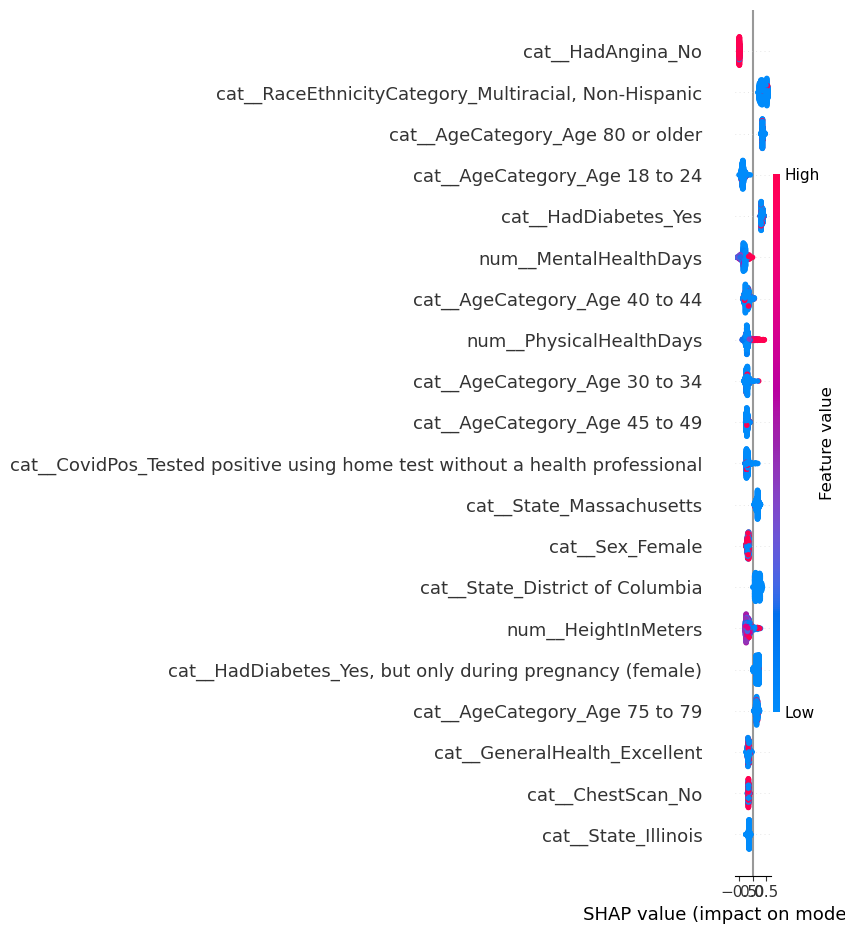

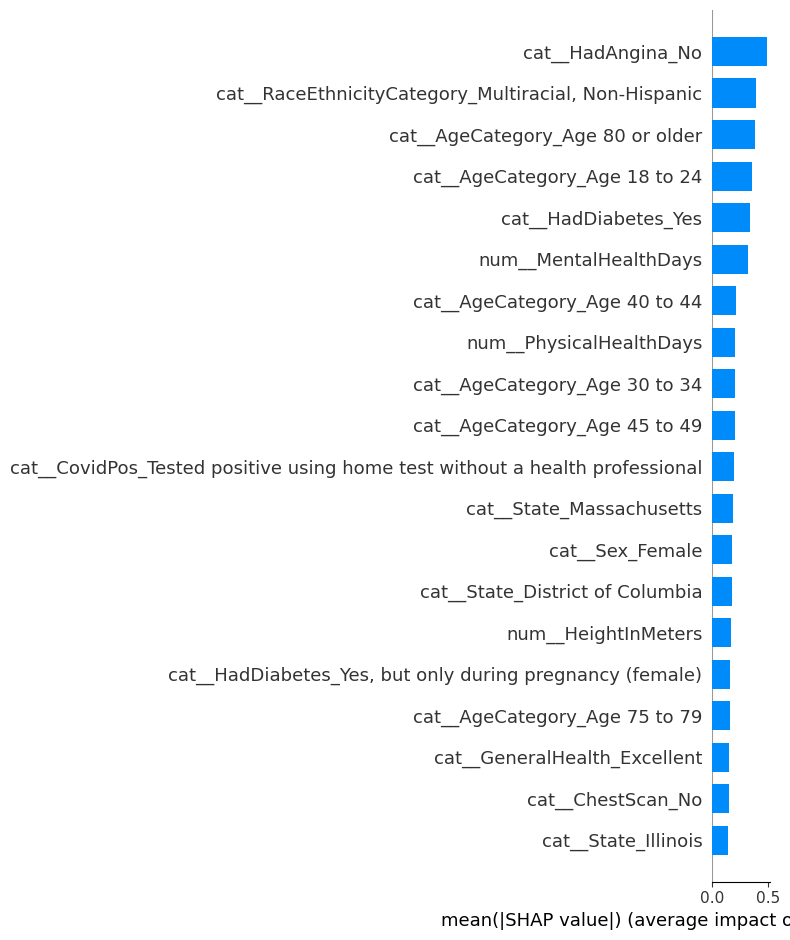

Memory after SHAP plots: 585.6 MB


In [16]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_matrix,
    Xt,
    feature_names=transformed_feature_names,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig(
    SHAP_DIR/"shap_summary_plot.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

shap.summary_plot(
    shap_matrix,
    Xt,
    feature_names=transformed_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig(
    SHAP_DIR/"shap_global_bar_plot.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

gc.collect()
print("Memory after SHAP plots:", f"{memory_mb():.1f} MB")

## 16. Free global SHAP arrays before local explanations

In [17]:
# Persisted plots/CSV are already saved.
# Free the larger temporary SHAP arrays before local explanations.
del shap_values
del shap_matrix
del Xt
del shap_raw

gc.collect()

print(
    "Memory after global SHAP cleanup:",
    f"{memory_mb():.1f} MB"
)

Memory after global SHAP cleanup: 585.6 MB


## 17. Local SHAP examples

In [18]:
case_rows=[]

for case_type in ["TP","FN","FP","TN"]:
    subset=analysis_df[analysis_df["_error_type"]==case_type]

    if len(subset)==0:
        continue

    if case_type=="FN":
        row=subset.sort_values("_score",ascending=False).iloc[0]
    elif case_type=="FP":
        row=subset.sort_values("_score",ascending=True).iloc[0]
    else:
        row=subset.sample(1,random_state=42).iloc[0]

    case_rows.append({
        "case_type":case_type,
        "row_index":int(row.name),
        "actual":int(row["_actual"]),
        "prediction":int(row["_prediction"]),
        "score":float(row["_score"])
    })

local_cases=pd.DataFrame(case_rows)
display(local_cases)

local_cases.to_csv(
    SHAP_DIR/"local_shap_cases.csv",
    index=False
)

all_local=[]

for _,case in local_cases.iterrows():
    idx=int(case["row_index"])

    row_t = preprocessor.transform(
        analysis_df.loc[[idx], FULL_FEATURES]
    )

    if hasattr(row_t,"toarray"):
        row_t=row_t.toarray()

    vals=explainer.shap_values(row_t)

    if isinstance(vals,list):
        vals = vals[1] if len(vals)==2 else vals[0]

    vals=np.asarray(vals)[0]

    t=pd.DataFrame({
        "feature":transformed_feature_names,
        "shap_value":vals,
        "abs_shap":np.abs(vals)
    }).sort_values(
        "abs_shap",
        ascending=False
    ).head(15)

    t["case_type"]=case["case_type"]
    t["row_index"]=idx
    t["score"]=case["score"]

    all_local.append(t)

    del row_t, vals
    gc.collect()

if all_local:
    local_explanations=pd.concat(
        all_local,
        ignore_index=True
    )

    display(
        local_explanations.head(60).round(4)
    )

    local_explanations.to_csv(
        SHAP_DIR/"local_shap_explanations.csv",
        index=False
    )

print(
    "Memory after local SHAP:",
    f"{memory_mb():.1f} MB"
)

,case_type,row_index,actual,prediction,score
0,TP,95280,1,1,0.956037
1,FN,272423,1,0,0.519850
2,FP,2102,0,1,0.520002
3,TN,199668,0,0,0.313800


,feature,shap_value,abs_shap,case_type,row_index,score
0,cat__HadAngina_No,-0.4925,0.4925,TP,95280,0.9560
1,"cat__RaceEthnicityCategory_Multiracial, Non-Hi...",0.3864,0.3864,TP,95280,0.9560
2,cat__AgeCategory_Age 80 or older,0.3652,0.3652,TP,95280,0.9560
3,cat__AgeCategory_Age 18 to 24,-0.3652,0.3652,TP,95280,0.9560
4,cat__HadDiabetes_Yes,0.3091,0.3091,TP,95280,0.9560
5,num__MentalHealthDays,-0.2938,0.2938,TP,95280,0.9560
6,num__HeightInMeters,-0.2398,0.2398,TP,95280,0.9560
7,cat__AgeCategory_Age 45 to 49,-0.2302,0.2302,TP,95280,0.9560
8,cat__AgeCategory_Age 30 to 34,-0.2193,0.2193,TP,95280,0.9560
9,num__PhysicalHealthDays,-0.2158,0.2158,TP,95280,0.9560


Memory after local SHAP: 674.9 MB


## 18. Governance summary

In [19]:
triggered = fairness_summary[
    fairness_summary["governance_trigger"]=="INVESTIGATE"
]["dimension"].tolist()

governance = {
    "project": PROJECT_NAME,
    "candidate_model": CANDIDATE_MODEL,
    "frozen_threshold": SELECTED_THRESHOLD,
    "holdout_used": False,
    "historical_target_disclaimer":
        "HadHeartAttack is historical/self-reported; no future-event claim.",
    "shap_completed": True,
    "shap_sample_size": SHAP_SAMPLE_SIZE,
    "shap_is_causal": False,
    "fairness_dimensions_checked": list(fairness_tables.keys()),
    "fairness_triggered_dimensions": triggered,
    "false_negative_count": FN_COUNT,
    "false_positive_count": FP_COUNT,
    "stage7_status":
        "REVIEW REQUIRED" if triggered else "NO RECALL-GAP TRIGGER"
}

with open(
    GOVERNANCE_DIR/"stage7_governance_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(governance,f,indent=2)

print(json.dumps(governance,indent=2))

{
  "project": "Heart_Attack_Risk_Assessment",
  "candidate_model": "xgboost",
  "frozen_threshold": 0.52,
  "holdout_used": false,
  "historical_target_disclaimer": "HadHeartAttack is historical/self-reported; no future-event claim.",
  "shap_completed": true,
  "shap_sample_size": 1000,
  "shap_is_causal": false,
  "fairness_dimensions_checked": [
    "age",
    "sex",
    "race"
  ],
  "fairness_triggered_dimensions": [
    "age",
    "sex"
  ],
  "false_negative_count": 3963,
  "false_positive_count": 66229,
  "stage7_status": "REVIEW REQUIRED"
}


## 19. Log Stage 7 artifacts to MLflow

In [20]:
with mlflow.start_run(
    run_name=f"{TEAM_ID}_{STUDENT_ID}_stage7_responsible_ai"
) as run:

    mlflow.set_tags({
        "team_id":TEAM_ID,
        "student_id":STUDENT_ID,
        "project_name":PROJECT_NAME,
        "stage":"stage7_responsible_ai",
        "model":CANDIDATE_MODEL
    })

    mlflow.log_params({
        "frozen_threshold":SELECTED_THRESHOLD,
        "fairness_recall_gap_trigger":TRIGGER,
        "shap_sample_size":SHAP_SAMPLE_SIZE,
        "holdout_used":False
    })

    mlflow.log_metrics({
        "false_negative_count":float(FN_COUNT),
        "false_positive_count":float(FP_COUNT),
        "fairness_dimensions_triggered":float(len(triggered))
    })

    for folder in [
        FAIRNESS_DIR,
        SHAP_DIR,
        ERROR_DIR,
        GOVERNANCE_DIR
    ]:
        mlflow.log_artifacts(
            str(folder),
            artifact_path=f"stage7/{folder.name}"
        )

    print(
        "Stage 7 MLflow Run ID:",
        run.info.run_id
    )

Stage 7 MLflow Run ID: baf87de5eb064d3394aaec1af969caa8
🏃 View run team05_s502_stage7_responsible_ai at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/baf87de5eb064d3394aaec1af969caa8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


# Stage 7 completion criteria

- Frozen Stage 6 XGBoost model loaded.
- Frozen threshold reused.
- No retraining.
- Fairness evaluated on full OOF data.
- Recall-gap > 0.10 trigger applied.
- False-negative and false-positive analysis completed.
- Global SHAP computed on only 1000 sampled rows.
- Full transformed dataset never densified.
- Temporary SHAP arrays explicitly freed.
- Local SHAP generated one row at a time.
- Responsible-AI artifacts logged to MLflow.
- Locked holdout untouched.

## Next Stage — Stage 8
One-time locked holdout evaluation.